# CNOT Y-junction
This file contains analysis for CNOT Y-junction results (initial scan and full scan).

## Initial scan
### Overall error rate

In [28]:
%load_ext autoreload
%autoreload 2

# Initial scan
from analysis_utils import load_ft_scan, plot_rate_scan

initial_scan = load_ft_scan(
    "../results/cnot_yjunction/initial_scan",
    p_values=[0.006, 0.008, 0.010, 0.012, 0.014, 0.016, 0.018, 0.020],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=1,
    failure_fields={
        "target": "target_logical_failures",
        "control": "control_logical_failures",
    },
)
initial_scan.print_summary()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 38 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1]]


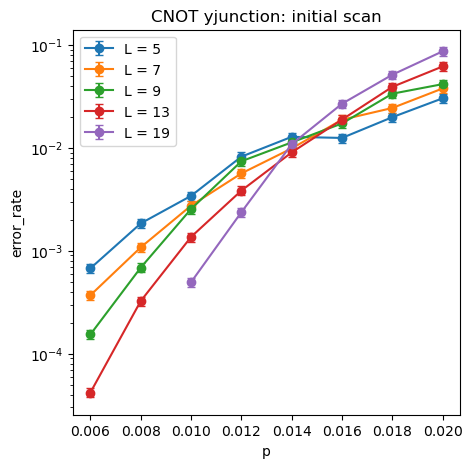

In [29]:
plot_rate_scan(
    initial_scan,
    title="CNOT yjunction: initial scan",
    ylabel="error_rate",
)


### Control error rate

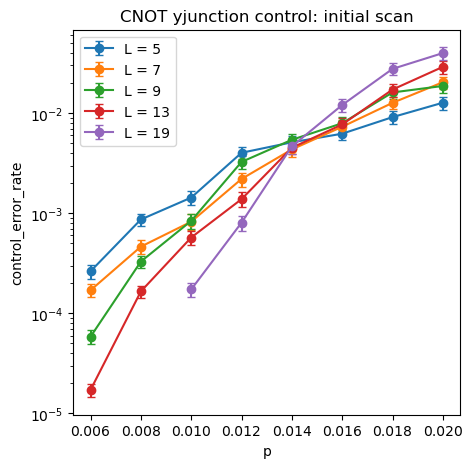

In [30]:
plot_rate_scan(
    initial_scan,
    rate_name="control",
    title="CNOT yjunction control: initial scan",
    ylabel="control_error_rate",
)


### Target error rate

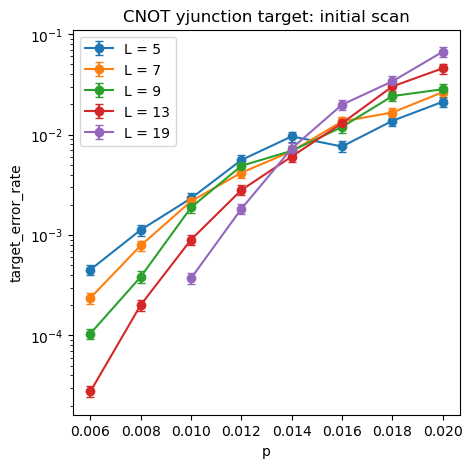

In [31]:
plot_rate_scan(
    initial_scan,
    rate_name="target",
    title="CNOT yjunction target: initial scan",
    ylabel="target_error_rate",
)


## Full scan
### Overall error rate

In [32]:
# Full scan
from analysis_utils import (
    display_finite_size_scaling_fit,
    display_fit_summary,
    fit_finite_size_scaling,
)

# Both control and target fits use this scaling-polynomial degree.
fit_degree = 2

full_scan = load_ft_scan(
    "../results/cnot_yjunction/full_scan/T∕2_CNOT_T∕2_2T",
    p_values=[0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=5,
    failure_fields={
        "target": "target_logical_failures",
        "control": "control_logical_failures",
    },
)
full_scan.print_summary()


Loaded 250 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]]


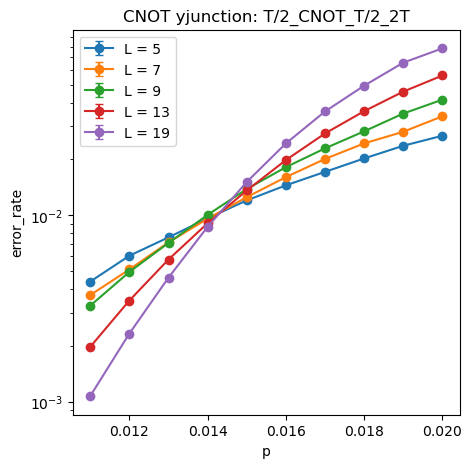

In [33]:
plot_rate_scan(
    full_scan,
    title="CNOT yjunction: T/2_CNOT_T/2_2T",
    ylabel="error_rate",
)


### Control error rate

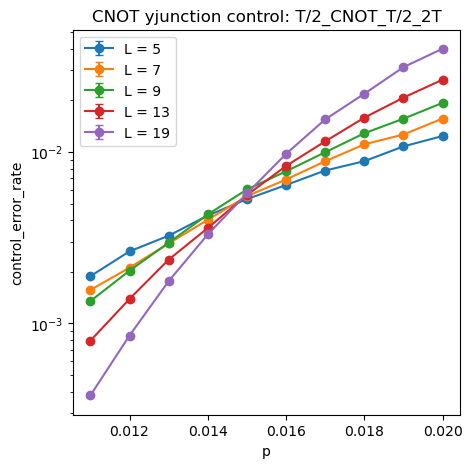

#### Finite-size scaling fit: Y-junction full scan — control

Degree-2 model: $P_L(p)=A+Bx+Cx^{2}$, with $x=(p-p_c)L^{1/\nu}$. The fit uses $p \in [0.011, 0.020]$ and $L \in [5, 7, 9, 13, 19]$.

| Quantity | Fit result |
|---|---:|
| $p_c$ | 0.01428(3) |
| $p_c$ (%) | 1.428(3) |
| $\nu$ | 1.35(2) |
| $A$ | 0.00462(4) |
| $B$ | 0.301(7) |
| $C$ | 5.4(2) |
| $\chi^2 / \mathrm{dof}$ | 725.66 / 45 = 16.13 |
| goodness-of-fit $p$-value | 1.28e-123 |

> **Fit-quality warning:** the degree-2 scaling model is rejected at the 5% level for this window. The covariance errors are statistical only; vary the degree, fit window, and minimum $L$ before quoting a final uncertainty.

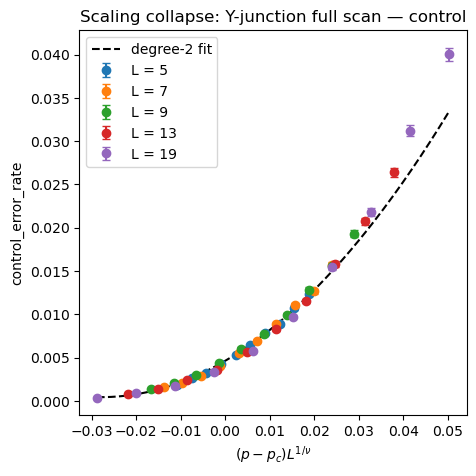

In [34]:
plot_rate_scan(
    full_scan,
    rate_name="control",
    title="CNOT yjunction control: T/2_CNOT_T/2_2T",
    ylabel="control_error_rate",
)

fit_yjunction_control = fit_finite_size_scaling(
    full_scan,
    rate_name="control",
    label="Y-junction full scan — control",
    polynomial_degree=fit_degree,
)
display_finite_size_scaling_fit(fit_yjunction_control, "control_error_rate")


### Target error rate

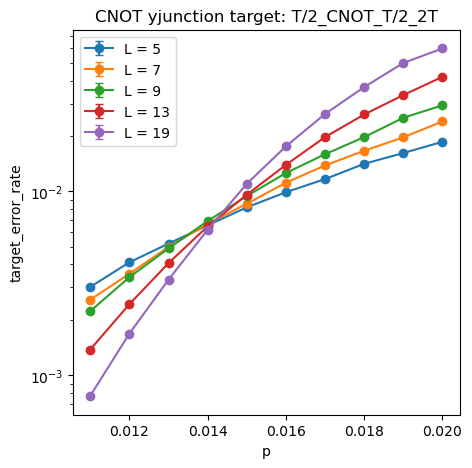

#### Finite-size scaling fit: Y-junction full scan — target

Degree-2 model: $P_L(p)=A+Bx+Cx^{2}$, with $x=(p-p_c)L^{1/\nu}$. The fit uses $p \in [0.011, 0.020]$ and $L \in [5, 7, 9, 13, 19]$.

| Quantity | Fit result |
|---|---:|
| $p_c$ | 0.01389(2) |
| $p_c$ (%) | 1.389(2) |
| $\nu$ | 1.29(1) |
| $A$ | 0.00660(5) |
| $B$ | 0.407(7) |
| $C$ | 7.2(2) |
| $\chi^2 / \mathrm{dof}$ | 535.62 / 45 = 11.90 |
| goodness-of-fit $p$-value | 3.55e-85 |

> **Fit-quality warning:** the degree-2 scaling model is rejected at the 5% level for this window. The covariance errors are statistical only; vary the degree, fit window, and minimum $L$ before quoting a final uncertainty.

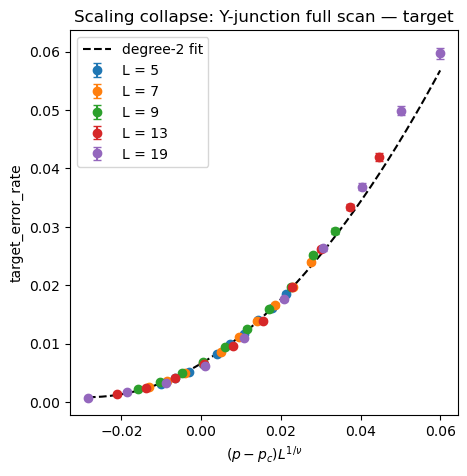

## Y-junction full-scan fit summary

| Timing and block | degree | $p_c$ | $p_c$ (%) | $\nu$ | $\chi^2 / \mathrm{dof}$ | fit $p$-value |
|---|---:|---:|---:|---:|---:|---:|
| Y-junction full scan — control | 2 | 0.01428(3) | 1.428(3) | 1.35(2) | 16.13 | 1.28e-123 |
| Y-junction full scan — target | 2 | 0.01389(2) | 1.389(2) | 1.29(1) | 11.90 | 3.55e-85 |

In [35]:
plot_rate_scan(
    full_scan,
    rate_name="target",
    title="CNOT yjunction target: T/2_CNOT_T/2_2T",
    ylabel="target_error_rate",
)

fit_yjunction_target = fit_finite_size_scaling(
    full_scan,
    rate_name="target",
    label="Y-junction full scan — target",
    polynomial_degree=fit_degree,
)
display_finite_size_scaling_fit(fit_yjunction_target, "target_error_rate")
display_fit_summary(
    [fit_yjunction_control, fit_yjunction_target],
    title="Y-junction full-scan fit summary",
)
